In [2]:
# Cell 1: Create project folder structure programmatically
import os

folders = [
    "data",
    "notebooks",
    "models",
    "src",
    "app"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)  # exist_ok avoids error if folder already exists

print("Project structure created successfully.")

Project structure created successfully.


In [3]:
# Cell 2: Verify TensorFlow and GPU availability
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
# If GPU list is empty, training will run on CPU (slower but still works for this project)

TensorFlow Version: 2.19.0
GPU Available: []


In [4]:
# Cell 3: Define dataset paths (update if your local path differs)
TRAIN_DIR = "data/asl_alphabet_train/asl_alphabet_train"
TEST_DIR = "data/asl_alphabet_test/asl_alphabet_test"

print("Train path exists:", os.path.exists(TRAIN_DIR))
print("Test path exists:", os.path.exists(TEST_DIR))

Train path exists: True
Test path exists: True


In [5]:
# Cell 1: List all classes and count images per class
import os

class_counts = {}

for class_name in sorted(os.listdir(TRAIN_DIR)):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images

print("Total classes found:", len(class_counts))
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

Total classes found: 29
A: 3000 images
B: 3000 images
C: 3000 images
D: 3000 images
E: 3000 images
F: 3000 images
G: 3000 images
H: 3000 images
I: 3000 images
J: 3000 images
K: 3000 images
L: 3000 images
M: 3000 images
N: 3000 images
O: 3000 images
P: 3000 images
Q: 3000 images
R: 3000 images
S: 3000 images
T: 3000 images
U: 3000 images
V: 3000 images
W: 3000 images
X: 3000 images
Y: 3000 images
Z: 3000 images
del: 3000 images
nothing: 3000 images
space: 3000 images


In [6]:
# Cell 2: Check image dimensions (sample a few images)
from PIL import Image
import random

sample_class = random.choice(list(class_counts.keys()))
sample_class_path = os.path.join(TRAIN_DIR, sample_class)
sample_images = os.listdir(sample_class_path)[:5]

for img_name in sample_images:
    img_path = os.path.join(sample_class_path, img_name)
    with Image.open(img_path) as img:
        print(f"{img_name}: size={img.size}, mode={img.mode}")
        # size = (width, height), mode = 'RGB' expected

I1.jpg: size=(200, 200), mode=RGB
I10.jpg: size=(200, 200), mode=RGB
I100.jpg: size=(200, 200), mode=RGB
I1000.jpg: size=(200, 200), mode=RGB
I1001.jpg: size=(200, 200), mode=RGB


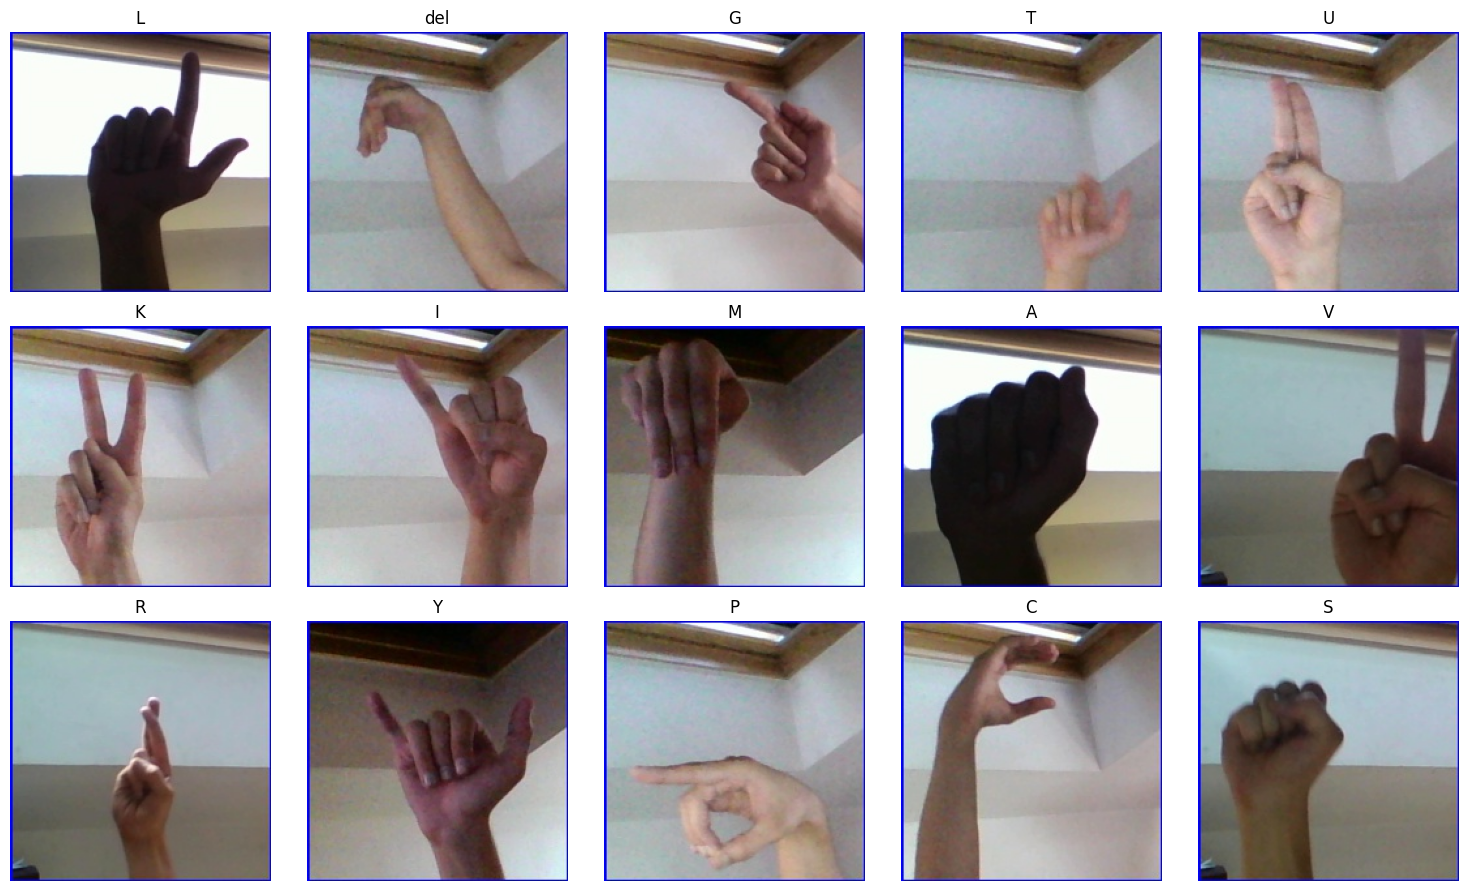

In [7]:
# Cell 3: Visualize random sample images from different classes
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_classes = random.sample(list(class_counts.keys()), 15)

for ax, cls in zip(axes.flatten(), sample_classes):
    class_path = os.path.join(TRAIN_DIR, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")  # hide axis ticks for cleaner visualization

plt.tight_layout()
plt.show()

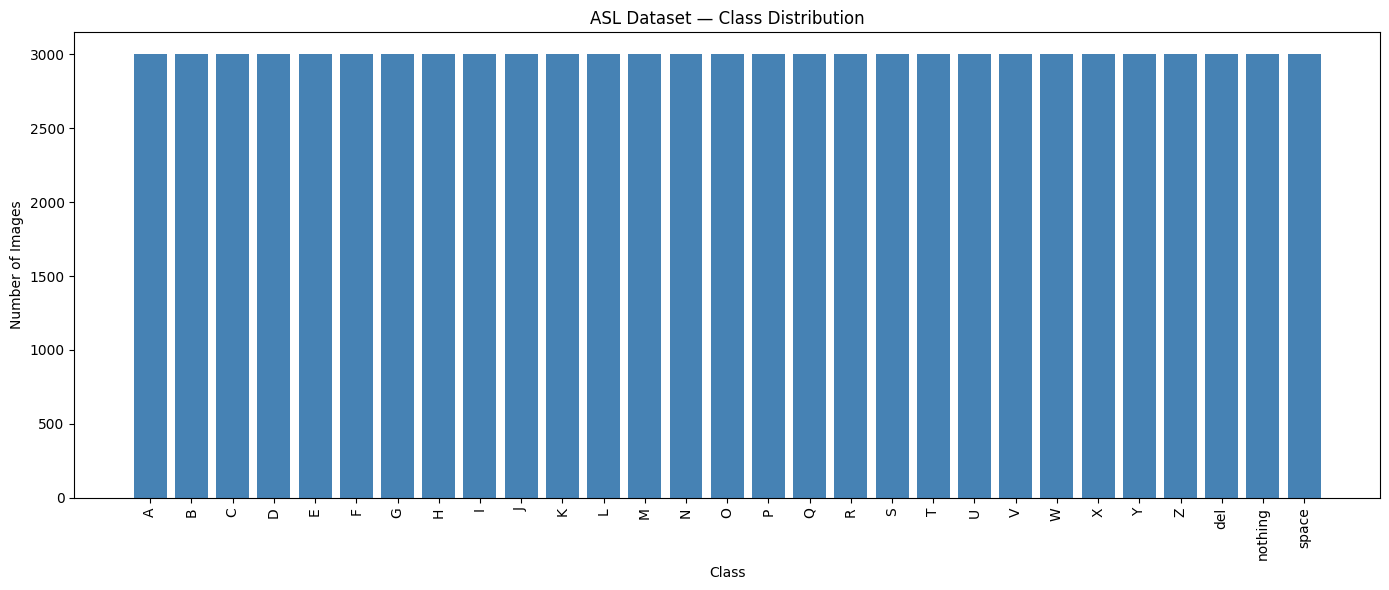

In [8]:
# Cell 4: Class distribution bar plot (confirms balance)
plt.figure(figsize=(14, 6))
plt.bar(class_counts.keys(), class_counts.values(), color="steelblue")
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("ASL Dataset — Class Distribution")
plt.tight_layout()
plt.show()
# If all bars are roughly equal height -> dataset is balanced, no class weighting needed

In [9]:
# Cell 5: Quick corruption check (important before training on full data)
from PIL import UnidentifiedImageError

corrupted = []

for cls in class_counts.keys():
    class_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(class_path)[:50]:  # sample check, not full scan (CPU-friendly)
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()  # checks file integrity without fully decoding
        except (UnidentifiedImageError, OSError):
            corrupted.append(img_path)

print("Corrupted images found (sampled check):", len(corrupted))

Corrupted images found (sampled check): 0


In [10]:
# Cell 1: Create a held-out TEST set by physically copying a sample of images
# Why: flow_from_directory's validation_split only does train/val, 
# so we manually reserve test images first, untouched by any generator used in training.

import shutil
import random

TEST_SPLIT_DIR = "data/asl_alphabet_test_split"
os.makedirs(TEST_SPLIT_DIR, exist_ok=True)

IMAGES_PER_CLASS_FOR_TEST = 100  # reserved purely for final evaluation (Phase 6)

for cls in sorted(os.listdir(TRAIN_DIR)):
    src_class_path = os.path.join(TRAIN_DIR, cls)
    dst_class_path = os.path.join(TEST_SPLIT_DIR, cls)
    os.makedirs(dst_class_path, exist_ok=True)

    all_images = os.listdir(src_class_path)
    test_images = random.sample(all_images, IMAGES_PER_CLASS_FOR_TEST)

    for img_name in test_images:
        src_file = os.path.join(src_class_path, img_name)
        dst_file = os.path.join(dst_class_path, img_name)
        if not os.path.exists(dst_file):
            shutil.copy(src_file, dst_file)  # copy, not move -> original train folder stays intact for now

print("Test split created with", IMAGES_PER_CLASS_FOR_TEST, "images per class.")

Test split created with 100 images per class.


In [22]:
# ---------------------------------------------------------
# ONE-TIME SETUP (ALREADY EXECUTED) — DO NOT RE-RUN
# This block created data/asl_alphabet_train_subset on disk
# with 1200 images/class, excluding test-split images.
# Commented out to avoid accidental re-copy / uneven counts.
# ---------------------------------------------------------

TRAIN_SUBSET_DIR = "data/asl_alphabet_train_subset"   # keep — used by generators later
IMAGES_PER_CLASS_FOR_TRAIN = 1200                      # keep — used for reference/README

# os.makedirs(TRAIN_SUBSET_DIR, exist_ok=True)
#
# for cls in sorted(os.listdir(TRAIN_DIR)):
#     src_class_path = os.path.join(TRAIN_DIR, cls)
#     dst_class_path = os.path.join(TRAIN_SUBSET_DIR, cls)
#     os.makedirs(dst_class_path, exist_ok=True)
#
#     test_used = set(os.listdir(os.path.join(TEST_SPLIT_DIR, cls)))
#     remaining_images = [img for img in os.listdir(src_class_path) if img not in test_used]
#
#     subset_images = random.sample(remaining_images, IMAGES_PER_CLASS_FOR_TRAIN)
#
#     for img_name in subset_images:
#         src_file = os.path.join(src_class_path, img_name)
#         dst_file = os.path.join(dst_class_path, img_name)
#         if not os.path.exists(dst_file):
#             shutil.copy(src_file, dst_file)
#
# print("Training subset created with", IMAGES_PER_CLASS_FOR_TRAIN, "images per class.")

print("Using existing training subset at:", TRAIN_SUBSET_DIR)

Using existing training subset at: data/asl_alphabet_train_subset


In [12]:
# Cell 3: Define image preprocessing parameters
IMG_SIZE = 64        # 64x64 -> small enough for CPU training, still enough detail for hand shapes
BATCH_SIZE = 32       # small batch -> lower RAM usage per training step
NUM_CLASSES = 29

In [13]:
# Cell 4: Create ImageDataGenerators with augmentation (train) and without (validation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training generator: includes augmentation + rescaling + validation_split
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalization: pixel values 0-255 -> 0-1
    rotation_range=15,        # randomly rotate images up to 15 degrees
    zoom_range=0.1,           # randomly zoom in/out by 10%
    width_shift_range=0.1,    # randomly shift image horizontally by 10%
    height_shift_range=0.1,   # randomly shift image vertically by 10%
    validation_split=0.15     # reserve 15% of this subset for validation
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_SUBSET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),  # resize every image to 64x64
    batch_size=BATCH_SIZE,
    class_mode='categorical',          # one-hot encodes labels automatically
    subset='training',
    shuffle=True                       # shuffle to avoid the model learning class order
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_SUBSET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False                      # no need to shuffle validation data
)

Found 29580 images belonging to 29 classes.
Found 5220 images belonging to 29 classes.


In [14]:
# Cell 5: Create TEST generator (no augmentation, only rescaling — must reflect real-world data)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_SPLIT_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # keep order so predictions can be matched back to true labels later
)

Found 2900 images belonging to 29 classes.


In [15]:
# Cell 6: Inspect class index mapping (important for decoding predictions later)
print("Class indices:", train_generator.class_indices)
# This dict maps class name -> integer index, e.g. {'A': 0, 'B': 1, ...}
# We'll need this mapping in Phase 8 (Prediction Script) to convert model output back to letters

Class indices: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}


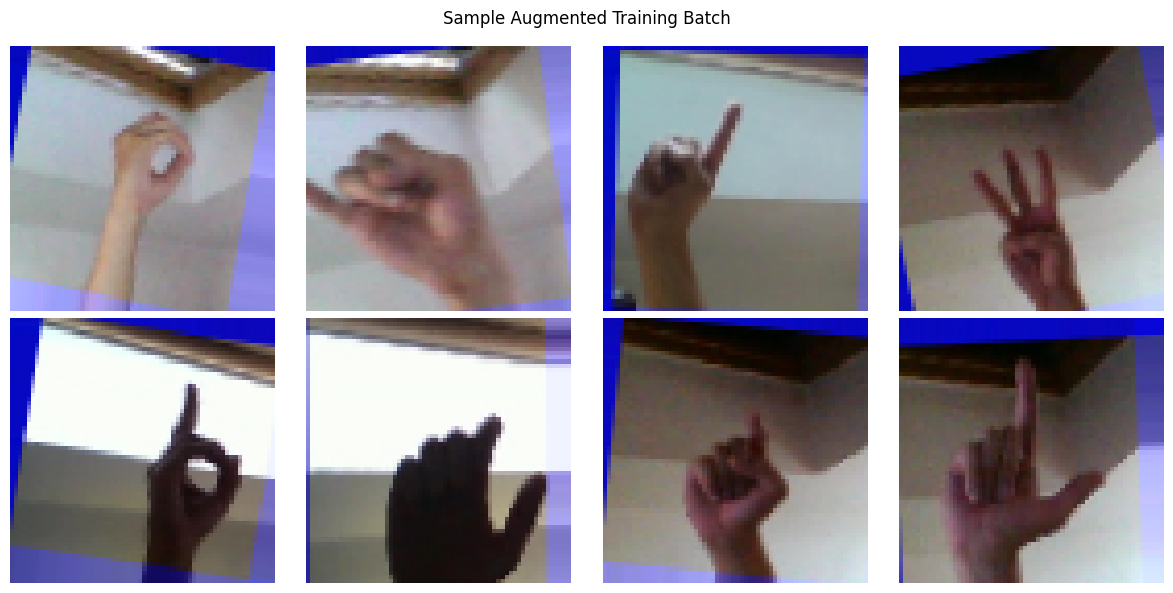

In [16]:
# Cell 7: Visualize one augmented batch to confirm augmentation is working
images, labels = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    ax.axis("off")
plt.suptitle("Sample Augmented Training Batch")
plt.tight_layout()
plt.show()

In [17]:
# Cell 1: Import required layers and Sequential API
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

In [18]:
# Cell 2: Build the CNN architecture
model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),  # explicit input layer: 64x64 RGB images

    # Block 1: detects low-level features (edges, simple curves)
    Conv2D(32, (3, 3), activation='relu'),   # 32 filters, 3x3 kernel
    MaxPooling2D(pool_size=(2, 2)),          # reduces spatial size by half

    # Block 2: detects mid-level features (finger shapes, contours)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: detects high-level features (combined hand shapes/gestures)
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten 3D feature maps into 1D vector for Dense layers
    Flatten(),

    # Fully connected layer to combine extracted features
    Dense(128, activation='relu'),
    Dropout(0.3),  # randomly disable 30% of neurons during training to reduce overfitting

    # Output layer: one probability per class, summing to 1
    Dense(NUM_CLASSES, activation='softmax')
])

In [19]:
# Cell 3: Display model summary - check parameter count and layer shapes
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,941 (2.62 MB)

 Trainable params: 686,941 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Cell 4: Manually verify output shape math after each block (educational check)
# Input: 64x64x3
# After Conv2D(32,3x3) no padding: 62x62x32 -> MaxPool(2x2): 31x31x32
# After Conv2D(64,3x3): 29x29x64 -> MaxPool(2x2): 14x14x64 (rounded down)
# After Conv2D(128,3x3): 12x12x128 -> MaxPool(2x2): 6x6x128
# Flatten: 6*6*128 = 4608 -> Dense(128) -> Dense(29)

print("Expected flatten size:", 6*6*128)

Expected flatten size: 4608


In [23]:
# Cell 1: Compile the model
model.compile(
    optimizer='adam',                    # Adam optimizer with default learning rate (0.001)
    loss='categorical_crossentropy',     # multi-class loss, matches our one-hot encoded labels
    metrics=['accuracy']                 # track accuracy during training for human-readable progress
)

In [24]:
# Cell 2: Define callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',       # watch validation loss (not training loss) to detect overfitting
    patience=5,                # stop if no improvement for 5 consecutive epochs
    restore_best_weights=True  # roll back to the best epoch's weights, not the last epoch
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                # halve the learning rate when triggered
    patience=3,                # wait 3 epochs of no improvement before reducing
    min_lr=1e-6                # don't let learning rate shrink below this floor
)

checkpoint = ModelCheckpoint(
    filepath="models/asl_cnn_best.keras",  # save in modern Keras format (explained in Phase 7)
    monitor='val_accuracy',
    save_best_only=True,        # only overwrite the file when validation accuracy improves
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

In [25]:
# Cell 3: Train the model
EPOCHS = 25

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

c:\Users\1abhi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.1969 - loss: 2.7742
Epoch 1: val_accuracy improved from -inf to 0.52031, saving model to models/asl_cnn_best.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 899s 968ms/step - accuracy: 0.1971 - loss: 2.7735 - val_accuracy: 0.5203 - val_loss: 1.5687 - learning_rate: 0.0010
Epoch 2/25
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6503 - loss: 1.0805
Epoch 2: val_accuracy improved from 0.52031 to 0.67107, saving model to models/asl_cnn_best.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 139s 150ms/step - accuracy: 0.6503 - loss: 1.0804 - val_accuracy: 0.6711 - val_loss: 1.0811 - learning_rate: 0.0010
Epoch 3/25
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7812 - loss: 0.6467
Epoch 3: val_accuracy improved from 0.67107 to 0.72529, saving model to models/asl_cnn_best.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 119s 128ms/step - accuracy: 0.7812 - loss: 0.6467 - val_accuracy: 0.7253 - val_loss: 0.9615 - learning_rate: 0.0010
Epoch 4/25

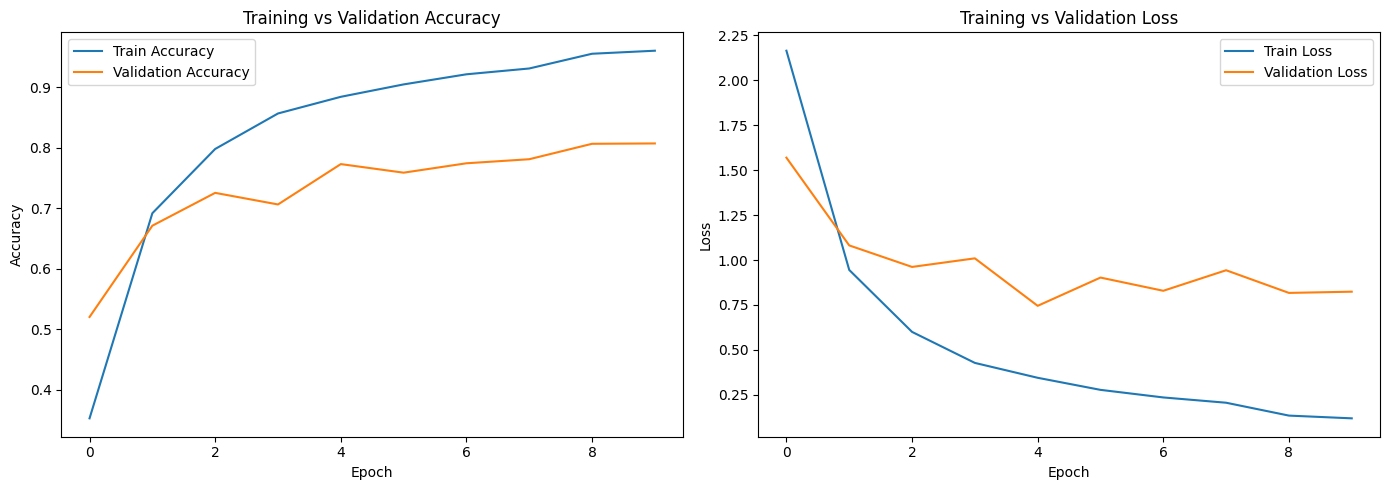

In [26]:
# Cell 4: Plot training history (accuracy and loss curves)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# Cell 1: Get predictions on the held-out test set (test_generator was created in Phase 3)
import numpy as np

test_generator.reset()  # ensure generator starts from the beginning, order matches labels

predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)   # convert probabilities -> class index

true_classes = test_generator.classes                 # true labels, in same order (shuffle=False)
class_labels = list(test_generator.class_indices.keys())  # ['A','B',...,'space']

print("Predictions shape:", predictions.shape)
print("Total test samples:", len(true_classes))

91/91 ━━━━━━━━━━━━━━━━━━━━ 62s 677ms/step
Predictions shape: (2900, 29)
Total test samples: 2900


In [28]:
# Cell 2: Overall test accuracy
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 95.34%
Test Loss: 0.1640


In [29]:
# Cell 3: Classification report - precision, recall, F1 per class
from sklearn.metrics import classification_report

report = classification_report(
    true_classes, 
    predicted_classes, 
    target_names=class_labels,
    digits=3
)
print(report)

              precision    recall  f1-score   support

           A      0.990     0.960     0.975       100
           B      0.926     1.000     0.962       100
           C      1.000     1.000     1.000       100
           D      0.980     1.000     0.990       100
           E      0.989     0.920     0.953       100
           F      1.000     0.990     0.995       100
           G      1.000     0.980     0.990       100
           H      0.962     1.000     0.980       100
           I      0.960     0.970     0.965       100
           J      1.000     0.970     0.985       100
           K      0.958     0.920     0.939       100
           L      0.971     1.000     0.985       100
           M      0.863     0.880     0.871       100
           N      0.851     0.860     0.856       100
           O      1.000     0.960     0.980       100
           P      1.000     0.970     0.985       100
           Q      0.971     0.990     0.980       100
           R      0.756    

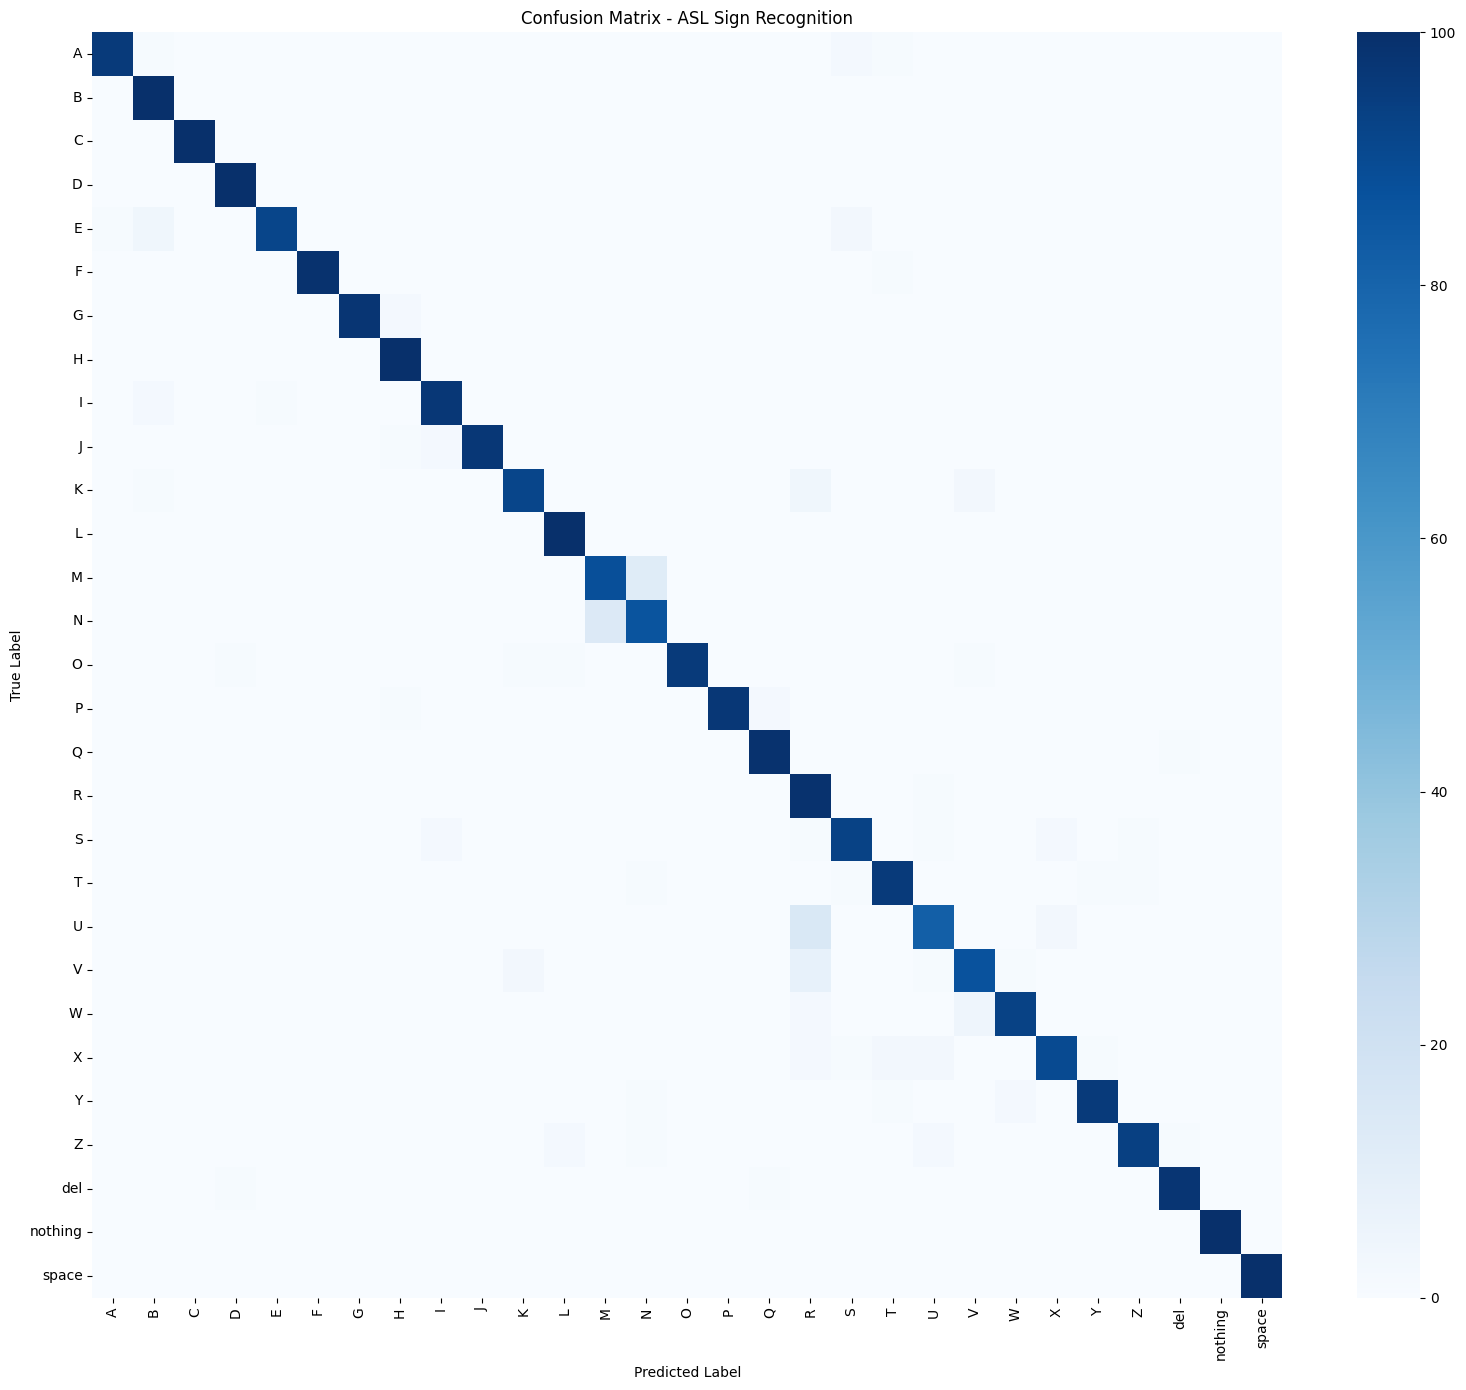

In [30]:
# Cell 4: Confusion matrix - visualize which classes get confused
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - ASL Sign Recognition')
plt.tight_layout()
plt.show()

In [31]:
# Cell 5: Identify top confused class pairs (easier to read than full matrix)
import pandas as pd

cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

confused_pairs = []
for true_label in class_labels:
    for pred_label in class_labels:
        if true_label != pred_label:
            count = cm_df.loc[true_label, pred_label]
            if count > 0:
                confused_pairs.append((true_label, pred_label, count))

confused_pairs_sorted = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

print("Top 15 most confused class pairs (True -> Predicted : Count):")
for true_label, pred_label, count in confused_pairs_sorted[:15]:
    print(f"{true_label} -> {pred_label} : {count}")

Top 15 most confused class pairs (True -> Predicted : Count):
U -> R : 15
N -> M : 14
M -> N : 12
V -> R : 8
W -> V : 5
E -> B : 4
K -> R : 4
E -> S : 3
K -> V : 3
U -> X : 3
V -> K : 3
X -> T : 3
X -> U : 3
A -> S : 2
G -> H : 2


Total misclassified: 135 out of 2900


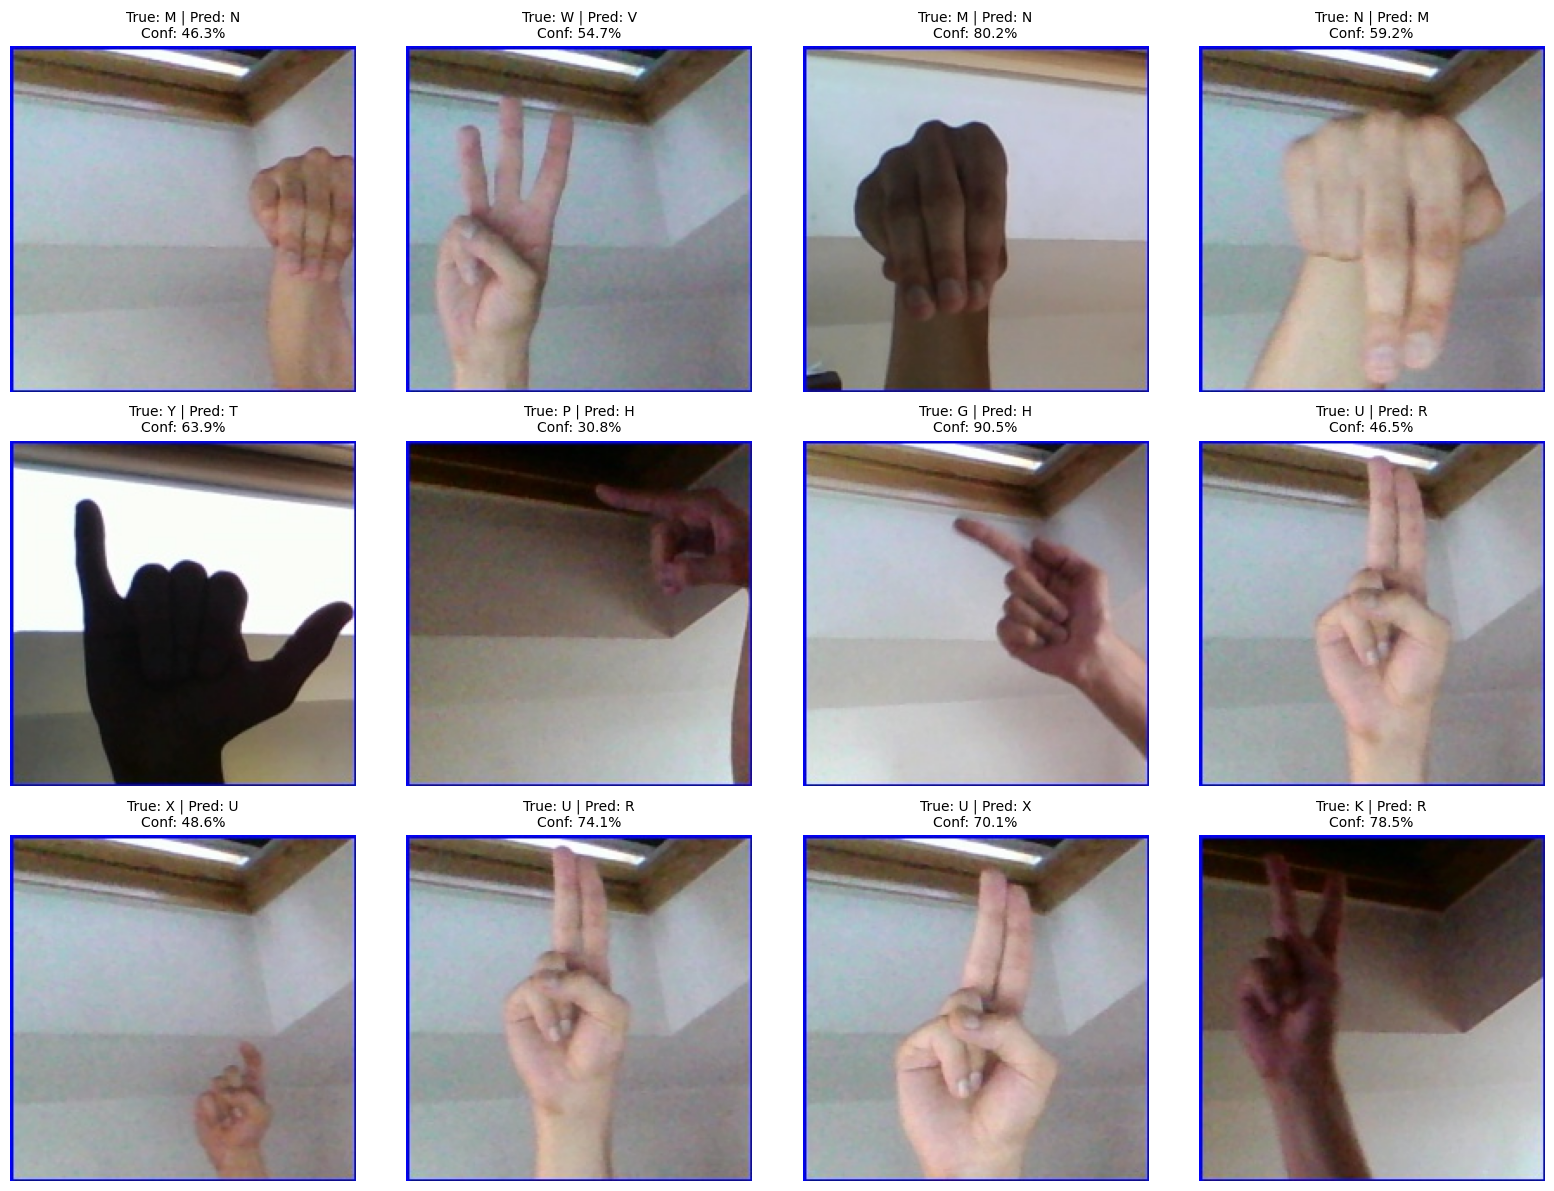

In [32]:
# Cell 6: Visualize sample misclassified images
misclassified_idx = np.where(predicted_classes != true_classes)[0]
print("Total misclassified:", len(misclassified_idx), "out of", len(true_classes))

# Get file paths from generator to load actual images
test_filepaths = test_generator.filepaths

sample_idx = np.random.choice(misclassified_idx, size=min(12, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, idx in zip(axes.flatten(), sample_idx):
    img = Image.open(test_filepaths[idx])
    ax.imshow(img)
    true_lbl = class_labels[true_classes[idx]]
    pred_lbl = class_labels[predicted_classes[idx]]
    confidence = predictions[idx][predicted_classes[idx]] * 100
    ax.set_title(f"True: {true_lbl} | Pred: {pred_lbl}\nConf: {confidence:.1f}%", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [33]:
# Cell 7: Per-class accuracy summary (sorted, weakest classes first)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

acc_df = pd.DataFrame({
    'Class': class_labels,
    'Accuracy': per_class_accuracy
}).sort_values('Accuracy')

print("Weakest performing classes:")
print(acc_df.head(10).to_string(index=False))

Weakest performing classes:
Class  Accuracy
    U      0.82
    N      0.86
    V      0.87
    M      0.88
    X      0.90
    E      0.92
    K      0.92
    S      0.93
    W      0.93
    Z      0.94


In [34]:
# Cell 1: Confirm the best model was already saved during training via ModelCheckpoint
import os

best_model_path = "models/asl_cnn_best.keras"
print("Best model exists:", os.path.exists(best_model_path))
print("File size (MB):", round(os.path.getsize(best_model_path) / (1024*1024), 2))

Best model exists: True
File size (MB): 7.91


In [35]:
# Cell 2: Save a clean, final copy with a descriptive name (good practice for project deliverables)
final_model_path = "models/asl_cnn_final.keras"
model.save(final_model_path)   # saves current in-memory model (best weights, since EarlyStopping restored them)

print("Final model saved at:", final_model_path)

Final model saved at: models/asl_cnn_final.keras


In [36]:
# Cell 3: Verify the saved model loads correctly and predicts identically
from tensorflow.keras.models import load_model

loaded_model = load_model(final_model_path)

# Sanity check: compare a prediction from original vs reloaded model
sample_batch_images, sample_batch_labels = next(test_generator)

original_pred = model.predict(sample_batch_images[:1], verbose=0)
reloaded_pred = loaded_model.predict(sample_batch_images[:1], verbose=0)

print("Predictions match:", np.allclose(original_pred, reloaded_pred))

Predictions match: True


In [37]:
# Cell 4: Save class_indices mapping alongside the model (CRITICAL for Phase 8/10/11)
# Why: the model only outputs numeric class indices (0-28). 
# Without this mapping saved, we can't convert predictions back to letters later,
# especially in standalone scripts (predict_image.py, webcam_predict.py) that won't have 
# access to train_generator.class_indices directly.

import json

class_indices_path = "models/class_indices.json"

with open(class_indices_path, "w") as f:
    json.dump(train_generator.class_indices, f, indent=4)

print("Class indices saved at:", class_indices_path)

Class indices saved at: models/class_indices.json


In [38]:
# Cell 5: Verify class_indices.json content
with open(class_indices_path, "r") as f:
    loaded_class_indices = json.load(f)

print(loaded_class_indices)

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}
